In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

sns.set_theme(style="whitegrid")
DATA_PATH = Path("Dataset_BobcatsCoyotesFoxes-1.csv")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# Midterm Analysis: Bobcat, Coyote, and Gray Fox Scats

This notebook documents data cleaning, exploratory analysis, statistical testing, and figure generation for the midterm project.

## Research questions
1. Which morphological or biogeochemical traits distinguish between species?
2. What biological or ecological factors might explain these differences?

In [2]:
df = pd.read_csv(DATA_PATH)

categorical_cols = ["Species", "Month", "Site", "Location"]
binary_cols = ["Ropey", "Segmented", "Flat", "Scrape"]
integer_cols = ["Year", "Age", "Number"]
float_cols = ["Length", "Diameter", "Taper", "TI", "Mass", "d13C", "d15N", "CN"]

for col in categorical_cols:
    df[col] = df[col].astype("category")
for col in binary_cols + integer_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.shape)
print(df["Species"].value_counts())
print("Total missing values:", int(df.isna().sum().sum()))
print(df.isna().sum())

(110, 19)
Species
Bobcat     57
Coyote     28
GrayFox    25
Name: count, dtype: int64
Total missing values: 47
Species       0
Month         0
Year          0
Site          0
Location      0
Age           0
Number        0
Length        0
Diameter      6
Taper        17
TI           17
Mass          1
d13C          2
d15N          2
CN            2
Ropey         0
Segmented     0
Flat          0
Scrape        0
dtype: int64


In [3]:
morphological_numeric = ["Length", "Diameter", "Taper", "TI", "Mass"]
biogeochemical_numeric = ["d13C", "d15N", "CN"]
morphological_binary = ["Ropey", "Segmented", "Flat", "Scrape"]

numeric_trait_cols = morphological_numeric + biogeochemical_numeric
analysis_df = df.dropna(subset=["Species"] + numeric_trait_cols + morphological_binary).copy()


def benjamini_hochberg(pvalues):
    pvalues = np.array(pvalues, dtype=float)
    m = len(pvalues)
    order = np.argsort(pvalues)
    ranked = pvalues[order]
    adjusted = np.empty(m)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        prev = min(prev, ranked[i] * m / rank)
        adjusted[i] = prev
    out = np.empty(m)
    out[order] = np.clip(adjusted, 0, 1)
    return out

kw_rows = []
for trait in numeric_trait_cols:
    groups = [
        analysis_df.loc[analysis_df["Species"] == sp, trait].astype(float).dropna().values
        for sp in analysis_df["Species"].cat.categories
    ]
    stat, pval = kruskal(*groups)
    med = analysis_df.groupby("Species", observed=True)[trait].median().to_dict()
    kw_rows.append(
        {
            "trait": trait,
            "statistic": stat,
            "p_value": pval,
            "bobcat_median": med.get("Bobcat", np.nan),
            "coyote_median": med.get("Coyote", np.nan),
            "grayfox_median": med.get("GrayFox", np.nan),
        }
    )

kw_df = pd.DataFrame(kw_rows).sort_values("p_value")
kw_df["p_adj_bh"] = benjamini_hochberg(kw_df["p_value"])

In [4]:
chi_rows = []
for trait in morphological_binary:
    table = pd.crosstab(analysis_df["Species"], analysis_df[trait])
    chi2, pval, dof, _ = chi2_contingency(table)
    rates = analysis_df.groupby("Species", observed=True)[trait].mean().to_dict()
    chi_rows.append(
        {
            "trait": trait,
            "chi2": chi2,
            "dof": dof,
            "p_value": pval,
            "bobcat_rate": rates.get("Bobcat", np.nan),
            "coyote_rate": rates.get("Coyote", np.nan),
            "grayfox_rate": rates.get("GrayFox", np.nan),
        }
    )

chi_df = pd.DataFrame(chi_rows).sort_values("p_value")
chi_df["p_adj_bh"] = benjamini_hochberg(chi_df["p_value"])

display(kw_df)
display(chi_df)

print("Significant continuous traits (BH-adjusted p < 0.05):")
print(kw_df.loc[kw_df["p_adj_bh"] < 0.05, "trait"].tolist())
print("Significant binary traits (BH-adjusted p < 0.05):")
print(chi_df.loc[chi_df["p_adj_bh"] < 0.05, "trait"].tolist())

,trait,statistic,p_value,bobcat_median,coyote_median,grayfox_median,p_adj_bh
4,Mass,25.428733,0.000003,11.235,16.750,4.37,0.000024
7,CN,21.925553,0.000017,6.600,7.700,8.10,0.000047
6,d15N,21.893256,0.000018,6.565,8.875,5.87,0.000047
1,Diameter,18.686031,0.000088,18.000,21.100,15.80,0.000175
5,d13C,14.589182,0.000679,-27.880,-26.065,-27.57,0.001087
2,Taper,5.048294,0.080127,25.850,29.950,20.00,0.106836
0,Length,1.965024,0.374370,9.000,10.000,8.00,0.427851
3,TI,0.018762,0.990663,1.355,1.450,1.25,0.990663


,trait,chi2,dof,p_value,bobcat_rate,coyote_rate,grayfox_rate,p_adj_bh
1,Segmented,9.434856,2,0.008938,0.74,0.500000,0.352941,0.035753
3,Scrape,4.338372,2,0.114271,0.10,0.000000,0.000000,0.228541
0,Ropey,2.202512,2,0.332453,0.60,0.541667,0.764706,0.443271
2,Flat,0.000000,0,1.000000,0.00,0.000000,0.000000,1.000000


Significant continuous traits (BH-adjusted p < 0.05):
['Mass', 'CN', 'd15N', 'Diameter', 'd13C']
Significant binary traits (BH-adjusted p < 0.05):
['Segmented']


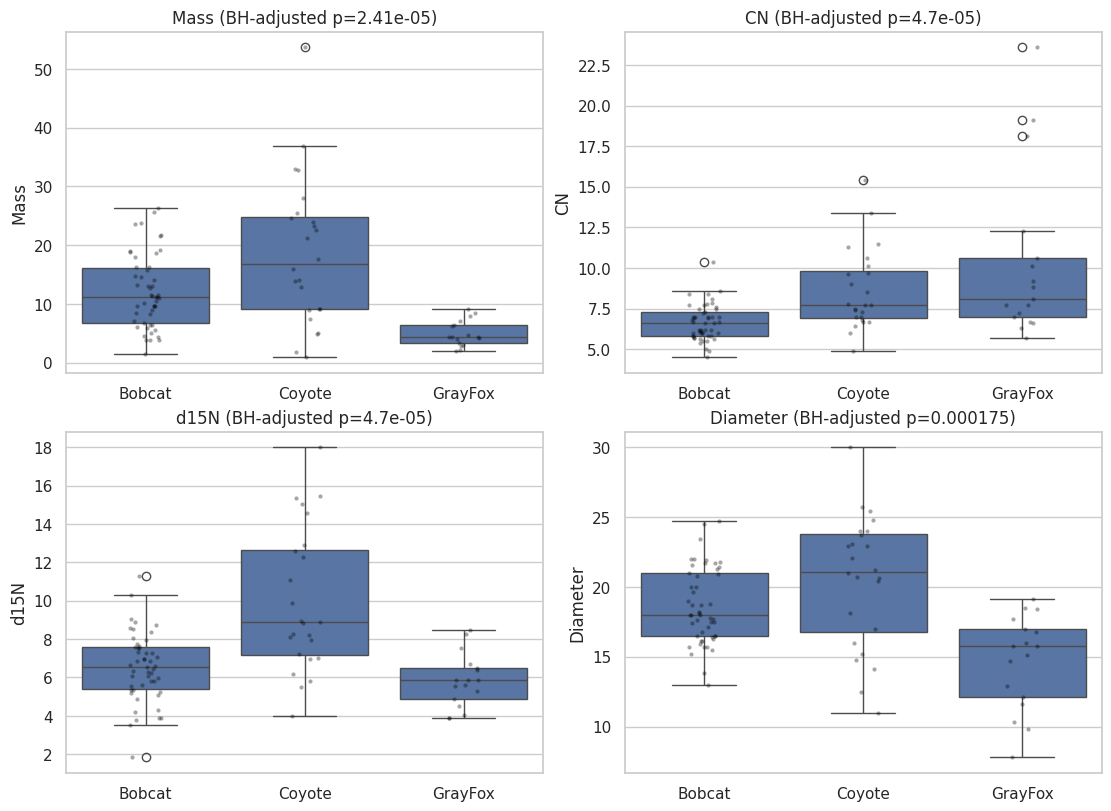

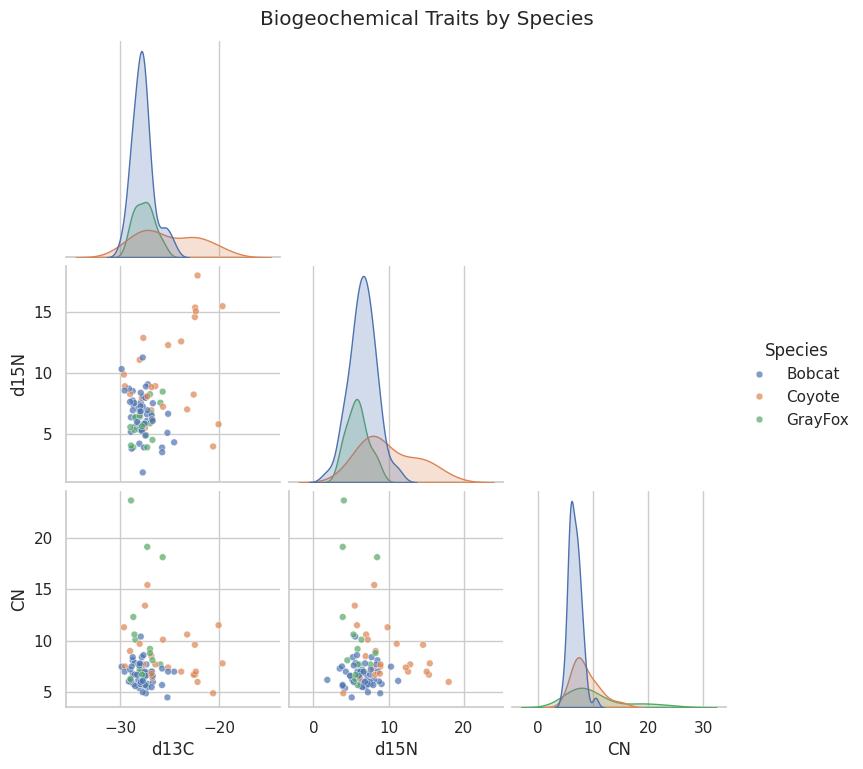

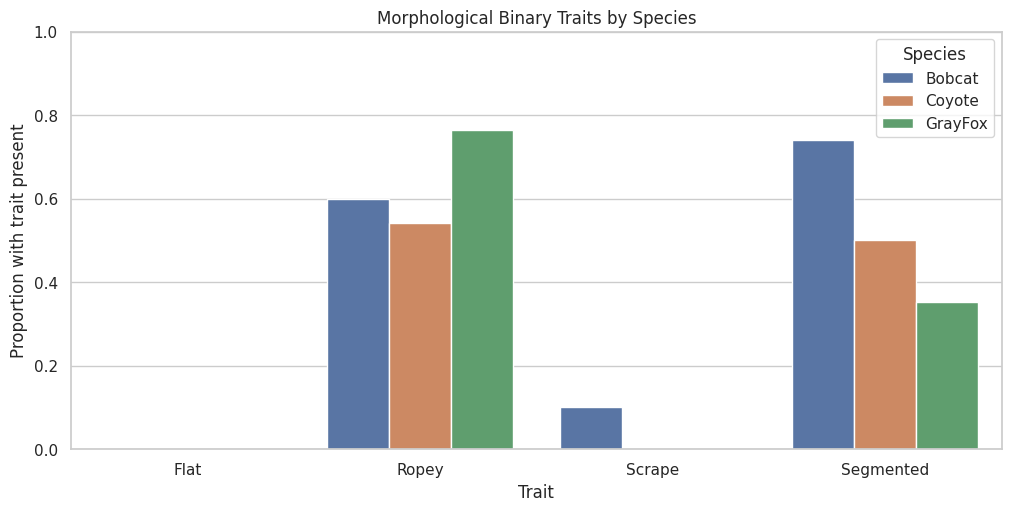

In [5]:
selected_numeric = kw_df.head(4)["trait"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, trait in zip(axes.flatten(), selected_numeric):
    sns.boxplot(data=analysis_df, x="Species", y=trait, ax=ax)
    sns.stripplot(data=analysis_df, x="Species", y=trait, color="black", alpha=0.35, size=3, ax=ax)
    p = kw_df.loc[kw_df["trait"] == trait, "p_adj_bh"].iloc[0]
    ax.set_title(f"{trait} (BH-adjusted p={p:.3g})")
    ax.set_xlabel("")
fig.savefig(OUT_DIR / "figure_numeric_boxplots.png", dpi=200)
plt.show()
plt.close(fig)

pair = sns.pairplot(
    analysis_df,
    vars=["d13C", "d15N", "CN"],
    hue="Species",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 24},
)
pair.fig.suptitle("Biogeochemical Traits by Species", y=1.02)
pair.savefig(OUT_DIR / "figure_biogeochemical_pairplot.png", dpi=180)
plt.show()
plt.close(pair.fig)

long_bin = analysis_df.melt(id_vars=["Species"], value_vars=morphological_binary, var_name="Trait", value_name="Present")
prev = long_bin.groupby(["Species", "Trait"], observed=True)["Present"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(data=prev, x="Trait", y="Present", hue="Species", ax=ax)
ax.set_ylabel("Proportion with trait present")
ax.set_ylim(0, 1)
ax.set_title("Morphological Binary Traits by Species")
fig.savefig(OUT_DIR / "figure_binary_prevalence.png", dpi=200)
plt.show()
plt.close(fig)

In [6]:
# Save core analysis tables for the report and dataset card.
kw_df.to_csv(OUT_DIR / "kruskal_results.csv", index=False)
chi_df.to_csv(OUT_DIR / "chi_square_results.csv", index=False)

dataset_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "species_counts": {k: int(v) for k, v in df["Species"].value_counts().to_dict().items()},
    "missing_total": int(df.isna().sum().sum()),
    "missing_by_column": {k: int(v) for k, v in df.isna().sum().to_dict().items()},
}
(OUT_DIR / "dataset_summary.json").write_text(json.dumps(dataset_summary, indent=2), encoding="utf-8")

print("Saved analysis outputs to:", OUT_DIR.resolve())

Saved analysis outputs to: /home/sam/notes/compSci/2621/midterm/outputs
